### E-Commerce US Dataset -- Data Ingestion

**Project Overview**

This project analyzes a US e-commerce transactional dataset modeled across 8 relational tables — customers, orders, order items, payments, reviews, products, sellers, and geolocation. The full dataset holds 1 million orders placed across 10 US metro areas by customers spanning 3 segments, purchasing from 2,000 products listed by 500 sellers. The primary objective is to understand the schema structure, assess data quality, and build a clean analytical base. A relational 10,000-order sample is extracted for fast EDA across all tables.

\Importing Necessary Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

\ Configuration - paths

In [30]:
RAW_PATH = r"c:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw\\"

FILES = [
    "customers.csv", "orders.csv", "order_items.csv",
    "order_payments.csv", "order_reviews.csv",
    "products.csv", "sellers.csv", "geolocation.csv"
]

In [31]:
orders     = pd.read_csv(RAW_PATH + "orders.csv")
customers   = pd.read_csv(RAW_PATH + "customers.csv")
order_items = pd.read_csv(RAW_PATH + "order_items.csv")
order_payments   = pd.read_csv(RAW_PATH + "order_payments.csv")
order_reviews    = pd.read_csv(RAW_PATH + "order_reviews.csv")
products    = pd.read_csv(RAW_PATH + "products.csv")
sellers     = pd.read_csv(RAW_PATH + "sellers.csv")
geolocation     = pd.read_csv(RAW_PATH + "geolocation.csv")

\Data Inspection

In [32]:
def explore_table(name, df):
    print("=" * 60)
    print(f"TABLE: {name}  |  Shape: {df.shape}")
    print("=" * 60)
    print("\n--- First 3 rows ---")
    print(df.head(3))
    print("\n--- Column dtypes ---")
    print(df.dtypes)
    print("\n")


In [33]:
explore_table("orders", orders)

TABLE: orders  |  Shape: (1000000, 8)

--- First 3 rows ---
                               order_id                           customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date  \
0  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20                          NaN                           NaN   
1  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44          2019-06-09 05:08:44           2019-06-14 05:08:44   
2  11bdf634-2b87-4d37-8d76-be1e7aff8f3b  89b0d980-868f-478d-a63b-5fea5f265f4f    delivered      2023-04-02 14:39:33  2023-04-02 23:42:33          2023-04-03 23:42:33           2023-04-08 23:42:33   

  order_estimated_delivery_date  
0           2026-01-04 08:33:20  
1           2019-06-16 05:08:44  
2           2023-04-10 23:42:33  

--- Co

**Insights**
- 1M rows with only 2 order statuses (delivered, canceled) — no intermediate states like "shipped" or "processing" exist in this dataset.
- All 8 columns are stored as `str` dtype including timestamps — `pd.to_datetime()` conversion is needed before any delivery-time calculation.
- 668 nulls in `order_delivered_carrier_date` and `order_delivered_customer_date` belong to canceled orders that never reached fulfillment.

In [34]:
explore_table("order_items",order_items)

TABLE: order_items  |  Shape: (2199819, 8)

--- First 3 rows ---
                               order_id  order_item_id                            product_id                             seller_id  shipping_limit_date   price  freight_value  discount_rate
0  720fd9e9-cdeb-4dec-a187-f71586eb085a              1  89804d82-33a1-4558-8fa2-9b0252a2a406  36c2b043-ccf4-4d9c-a0bb-4b8d28737fd7  2025-12-30 07:07:20  916.90          45.47            0.0
1  720fd9e9-cdeb-4dec-a187-f71586eb085a              2  ac10b78c-342e-4b50-9ea9-bddde7db2e79  09936504-415b-4f90-a5b8-ad15a5be67d0  2025-12-30 07:07:20  817.14         172.48            0.0
2  720fd9e9-cdeb-4dec-a187-f71586eb085a              3  f18e6310-0e75-4b7f-bc20-90ac1e7bd466  7d336012-7101-4a66-b6bc-c269620d8df9  2025-12-30 07:07:20   37.04          94.98            0.0

--- Column dtypes ---
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        s

**Insights**
- 2.2M rows against 1M orders → average ~2.2 items per order.
- `discount_rate` is applied at the item level, not per order.

In [35]:
explore_table("customers",customers)

TABLE: customers  |  Shape: (1000000, 9)

--- First 3 rows ---
                            customer_id                    customer_unique_id  customer_name customer_gender  customer_age  customer_zip_code_prefix customer_city customer_state customer_segment
0  1e2e2881-a0eb-4cb0-829f-a566e810d05f  d45cdff2-5195-41e2-a0e5-6fe597e378dd    James Ramos               M            47                     85037       Phoenix             AZ         Consumer
1  380b7418-308c-4bf7-b2bd-3ee446cb9ea6  35cee471-325e-4ad2-8e4e-7b169dc6df81  Brian Jackson               M            18                     90060   Los Angeles             CA         Consumer
2  89b0d980-868f-478d-a63b-5fea5f265f4f  c820d3a4-edd4-4b32-9605-22d97dcc8e5e    Debra Jones               F            61                     30398       Atlanta             GA         Consumer

--- Column dtypes ---
customer_id                   str
customer_unique_id            str
customer_name                 str
customer_gender               st

**Insights**
- 1M `customer_id` rows but only 7,898 unique `customer_unique_id` values in the sample — ~21% of orders are from returning customers placing new orders under a fresh `customer_id`.
- Coverage is limited to just 10 cities and 10 states — the dataset represents specific US metros, not a nationwide distribution.
- 3 customer segments (Consumer, Corporate, Home Office) and 2 genders are clean categorical columns, ready to use for segmentation without any preprocessing.

In [36]:
explore_table("order_reviews",order_reviews)

TABLE: order_reviews  |  Shape: (933748, 7)

--- First 3 rows ---
                              review_id                              order_id  review_score review_comment_title                          review_comment_message review_creation_date  \
0  0ba49642-47bb-4817-9cc2-bb9ded7de7c5  c0142972-63fa-4af2-8070-f583ab769847             5              Perfect     The quality is amazing. Delivery was quick.  2019-06-19 05:08:44   
1  4e540350-1d67-4f18-bfbb-66e45e16bbc5  11bdf634-2b87-4d37-8d76-be1e7aff8f3b             5                 Good  The service is excellent. Super fast shipping.  2023-04-12 23:42:33   
2  9bf68eb6-676d-4759-956e-564b7b90410c  d29b58ad-af2a-47b4-9214-b2664fb1fdba             5              Perfect           The item is fantastic. Arrived early!  2023-02-08 15:26:24   

  review_answer_timestamp  
0     2019-06-19 07:08:44  
1     2023-04-13 01:42:33  
2     2023-02-08 17:26:24  

--- Column dtypes ---
review_id                    str
order_id                 

**Insights**
- 933K reviews out of 1M orders (~93.4% review rate) — a very high response rate, likely platform-enforced after delivery.
- Only 14 unique `review_comment_title` values across 933K rows — titles are fixed labels (e.g., "Perfect", "Good"), not free-form customer text.
- `review_score` is clean with all 5 values (1–5) present and zero nulls — no imputation needed for this column.

In [37]:
explore_table("order_payments",order_payments)

TABLE: order_payments  |  Shape: (1149371, 5)

--- First 3 rows ---
                               order_id  payment_sequential payment_type  payment_installments  payment_value
0  720fd9e9-cdeb-4dec-a187-f71586eb085a                   1       paypal                     1        2084.01
1  c0142972-63fa-4af2-8070-f583ab769847                   1  credit_card                     6        1406.07
2  11bdf634-2b87-4d37-8d76-be1e7aff8f3b                   1      voucher                     1         911.30

--- Column dtypes ---
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object




**Insights**
- 1.15M rows for 1M orders — ~15% of orders are split across multiple payment methods.
- 7 payment types and up to 12 installments are present — installment-based credit card payments appear to be a common pattern.
- `payment_value` is recorded per sequential row, not as an order-level total — aggregation is required before joining payment data to orders.

In [38]:
explore_table("products",products)

TABLE: products  |  Shape: (2000, 10)

--- First 3 rows ---
                             product_id product_category_name                  product_name product_brand  product_weight_g  product_length_cm  product_height_cm  product_width_cm    cost   price
0  cdc4381f-fa67-41f2-a7d5-07f330097589                 books  When successful medical beat        Vertex               661                 18                 19                 9   22.45   42.42
1  1f0d68f8-18d7-47c6-8c73-ffd89a2a960a                  auto   Pulse Seat Cover Kit (M231)         Pulse              9662                 52                 12                25  124.84  148.16
2  f68621b0-8316-4cc4-9ba6-af209132acd6           electronics          Nova M247 Headphones          Nova              4287                 12                 18                15  704.26  843.43

--- Column dtypes ---
product_id                   str
product_category_name        str
product_name                 str
product_brand                str
p

**Insights**
- Only 2,000 products across 7 categories and 8 brands — a small, curated catalog rather than a long-tail marketplace.
- Both `cost` and `price` columns are available — gross margin per product is directly calculable without any external data.
- All 4 dimension columns (weight, length, height, width) are fully populated.

In [39]:
explore_table("sellers",sellers)

TABLE: sellers  |  Shape: (500, 8)

--- First 3 rows ---
                              seller_id seller_company_name seller_contact_name seller_contact_gender  seller_contact_age  seller_zip_code_prefix seller_city seller_state
0  82787b9a-3c5a-476a-9f1b-a5fc7d98c8cf         Johnson LLC      Holly Mcdaniel                     F                  57                   60633     Chicago           IL
1  75c29e4b-cc77-45c9-a3b6-7aa713f56126           Hicks LLC       Charles Casey                     M                  33                   30339     Atlanta           GA
2  d2bc11e3-2a8f-4d16-9b04-8db5008730de        Briggs-Brown      Daniel Serrano                     M                  33                   98193     Seattle           WA

--- Column dtypes ---
seller_id                   str
seller_company_name         str
seller_contact_name         str
seller_contact_gender       str
seller_contact_age        int64
seller_zip_code_prefix    int64
seller_city                 str
seller_state

**Insights**
- 500 sellers spread across the same 10 cities as customers — seller and buyer geography are intentionally co-located in this dataset.
- 493 unique company names out of 500 sellers — 7 sellers share a parent company name, suggesting a small number of multi-brand operators.
- Contact-level demographic columns (gender, age) are available for sellers — uncommon to see in a standard e-commerce dataset, but useful for seller profiling.

In [40]:
explore_table("geolocation",geolocation)

TABLE: geolocation  |  Shape: (11500, 5)

--- First 3 rows ---
   zip_code_prefix  geolocation_lat  geolocation_lng geolocation_city geolocation_state
0            10093        40.756378       -74.032669         New York                NY
1            10075        40.681693       -73.956079         New York                NY
2            10010        40.642143       -73.969978         New York                NY

--- Column dtypes ---
zip_code_prefix        int64
geolocation_lat      float64
geolocation_lng      float64
geolocation_city         str
geolocation_state        str
dtype: object




**Insights**
- 11,500 zip-level records covering only 10 cities — each metro contributes hundreds of zip codes as expected for large US cities.
- Lat/lng values are at 6 decimal-place precision — suitable for computing distances between customer and seller locations.
- No nulls across all 5 columns — the cleanest table in the dataset, requires no imputation or cleanup.

\Smart Relational Sampling

In [41]:
SAMPLE_SIZE=10000
print(f"Config set! Sample size = {SAMPLE_SIZE} rows per logical group")
orders = pd.read_csv(RAW_PATH + "orders.csv", nrows=SAMPLE_SIZE)

order_ids = set(orders["order_id"])
customer_ids = set(orders["customer_id"])

print(f"Loaded orders: {orders.shape[0]} rows")

def load_filtered(filename, key_column, valid_ids):
    df = pd.read_csv(RAW_PATH + filename)
    filtered = df[df[key_column].isin(valid_ids)].reset_index(drop=True)
    return filtered

# order_id 
order_items    = load_filtered("order_items.csv",    "order_id", order_ids)
order_payments = load_filtered("order_payments.csv", "order_id", order_ids)
order_reviews  = load_filtered("order_reviews.csv",  "order_id", order_ids)

# customer_id 
customers = load_filtered("customers.csv", "customer_id", customer_ids)

# order_items
product_ids = set(order_items["product_id"])
seller_ids  = set(order_items["seller_id"])

products = load_filtered("products.csv", "product_id", product_ids)
sellers  = load_filtered("sellers.csv",  "seller_id",  seller_ids)

# zip codes 
zips = set(customers["customer_zip_code_prefix"]) | set(sellers["seller_zip_code_prefix"])
geo = pd.read_csv(RAW_PATH + "geolocation.csv")
geolocation = geo[geo["zip_code_prefix"].isin(zips)].reset_index(drop=True)


Config set! Sample size = 10000 rows per logical group


Loaded orders: 10000 rows


In [42]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
}

print("===== SAMPLED DATA SUMMARY =====")
for name, df in tables.items():
    print(f"{name:18s} : {df.shape[0]:>6,} rows x {df.shape[1]} cols")

===== SAMPLED DATA SUMMARY =====
customers          : 10,000 rows x 9 cols
orders             : 10,000 rows x 8 cols
order_items        : 21,838 rows x 8 cols
order_payments     : 11,474 rows x 5 cols
order_reviews      :  9,332 rows x 7 cols
products           :  1,984 rows x 10 cols
sellers            :    500 rows x 8 cols
geolocation        : 11,255 rows x 5 cols


**Sampling Summary**
- 10k order records are taken forward for analysis
- `order_items` (21,838) is ~2.18x the order count, confirming an average of ~2.18 items per order across this sample.
- `order_reviews` (9,332) is exactly 668 short of 10,000 — the gap matches the null delivery-date count in orders, meaning canceled orders produce no reviews.
- `order_payments` (11,474) reflects split-payment orders; products (1,984) and sellers (500) are fully captured with no referential integrity loss in the sample.

\Data Dictionary

In [43]:
def make_data_dictionary(df, table_name):
    rows=[]
    for col in df.columns:
        rows.append({
            "table":table_name,
            "column":col,
            "dtype": str(df[col].dtype),
            "non_null_count": df[col].notna().sum(),
            "null_count": df[col].isna().sum(),
            "unique_values":df[col].nunique(),
            "sample_value":df[col].dropna().iloc[0] if df[col].notna().any() else None
        })
    return pd.DataFrame(rows)

all_dicts=[]
for name,df in tables.items():
    all_dicts.append(make_data_dictionary(df, name))

data_dictionary =pd.concat(all_dicts, ignore_index=True)
data_dictionary

,table,column,dtype,non_null_count,null_count,unique_values,sample_value
0,customers,customer_id,str,10000,0,10000,1e2e2881-a0eb-4cb0-829f-a566e810d05f
1,customers,customer_unique_id,str,10000,0,7898,d45cdff2-5195-41e2-a0e5-6fe597e378dd
2,customers,customer_name,str,10000,0,7510,James Ramos
3,customers,customer_gender,str,10000,0,2,M
4,customers,customer_age,int64,10000,0,53,47
5,customers,customer_zip_code_prefix,int64,10000,0,838,85037
6,customers,customer_city,str,10000,0,10,Phoenix
7,customers,customer_state,str,10000,0,10,AZ
8,customers,customer_segment,str,10000,0,3,Consumer
9,orders,order_id,str,10000,0,10000,720fd9e9-cdeb-4dec-a187-f71586eb085a


**Data Dictionary — Key Observations**
- Zero null values anywhere except the 668 delivery-date rows in orders — the dataset is unusually complete and requires minimal imputation work.
- Every timestamp column across all tables is typed as `str`.
- `customer_unique_id` uniqueness (7,898 vs 10,000 `customer_id` rows) confirms repeat buyers are present and identifiable.
- `order_status` has only 2 unique values (delivered, canceled) — binary classification between the two is clean and requires no label consolidation.

\Saving the sample dataset

In [44]:
for name,df in tables.items():
    df.to_csv(rf"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw_sample\{name}.csv",index= False)

data_dictionary.to_csv(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw_sample\data_dictionary.csv",index=False)

\ERD 

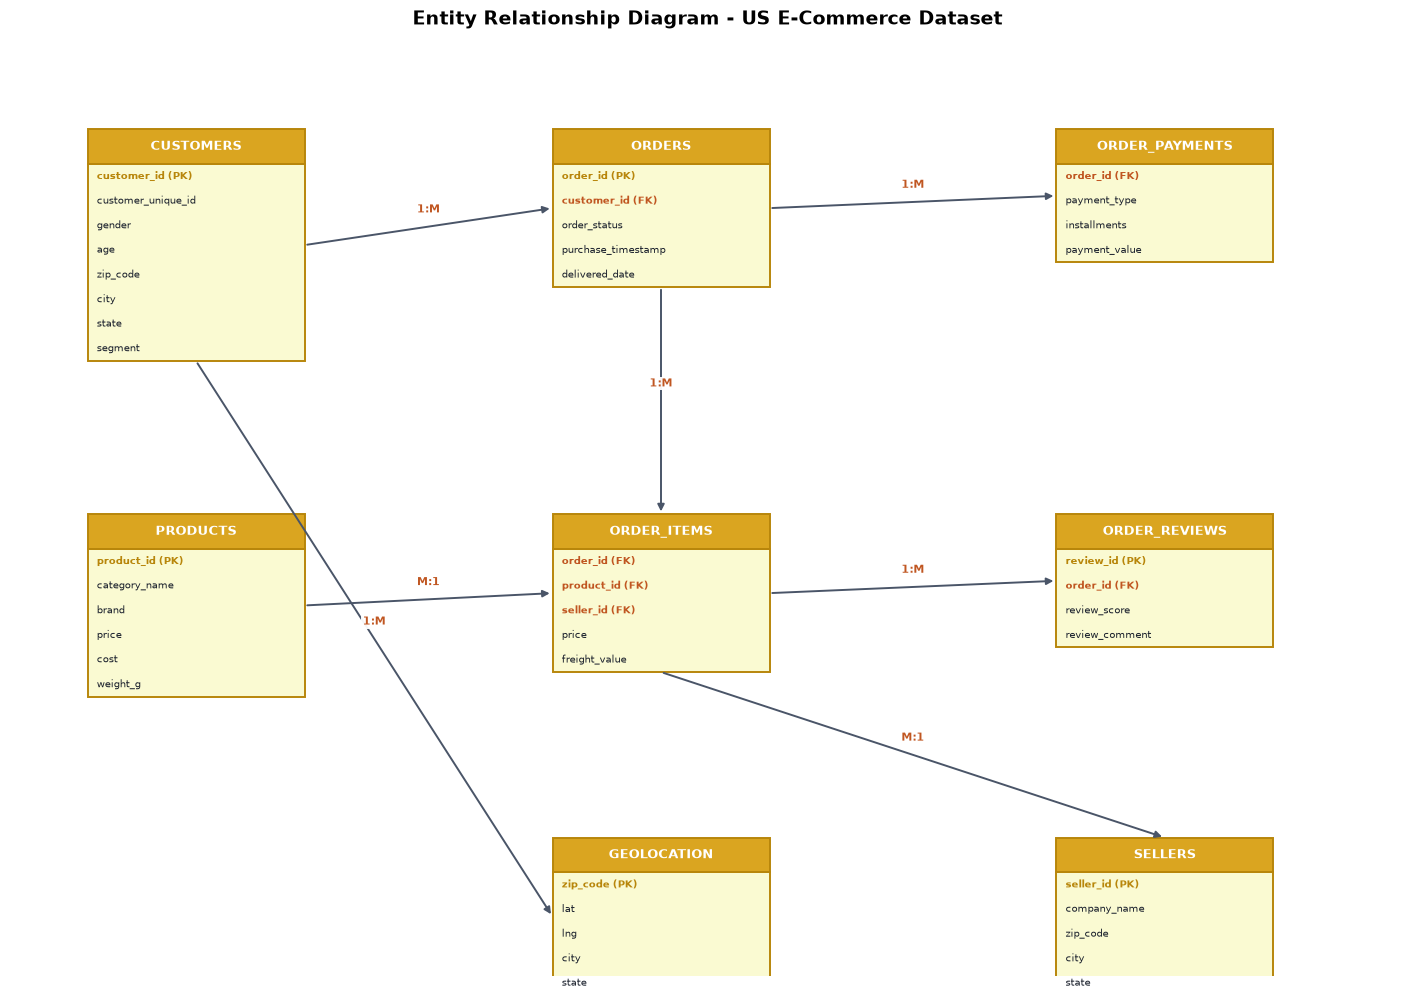

In [45]:
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18); ax.set_ylim(0, 12); ax.axis("off")

BOX_W, HDR_H, ROW_H = 2.8, 0.45, 0.32
boxes = {}

HDR_COLOR    = "#DAA520"   
BODY_COLOR   = "#FAFAD2"   
BORDER_COLOR = "#B8860B"   

def draw_table(name, columns, x, y_top):
    n = len(columns); body_h = n * ROW_H; total_h = HDR_H + body_h
    # Body
    ax.add_patch(plt.Rectangle((x, y_top - total_h), BOX_W, body_h,
                               fc=BODY_COLOR, ec=BORDER_COLOR, lw=1.4, zorder=2))
    # Header
    ax.add_patch(plt.Rectangle((x, y_top - HDR_H), BOX_W, HDR_H,
                               fc=HDR_COLOR, ec=BORDER_COLOR, lw=1.4, zorder=3))
    ax.text(x + BOX_W/2, y_top - HDR_H/2, name, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)
    # Columns
    for i, col in enumerate(columns):
        ry = y_top - HDR_H - (i + 0.5) * ROW_H
        color = "#B8860B" if "PK" in col else ("#c05621" if "FK" in col else "#1a202c")
        weight = "bold" if ("PK" in col or "FK" in col) else "normal"
        ax.text(x + 0.12, ry, col, ha="left", va="center",
                fontsize=7, color=color, fontweight=weight, zorder=4)
    boxes[name] = dict(L=x, R=x+BOX_W, T=y_top, B=y_top-total_h,
                       CX=x+BOX_W/2, CY=y_top-total_h/2)

def connect(t1, t2, label="", side1="R", side2="L"):
    b1, b2 = boxes[t1], boxes[t2]
    pts = {"L": (b1["L"], b1["CY"]), "R": (b1["R"], b1["CY"]),
           "T": (b1["CX"], b1["T"]), "B": (b1["CX"], b1["B"])}
    pte = {"L": (b2["L"], b2["CY"]), "R": (b2["R"], b2["CY"]),
           "T": (b2["CX"], b2["T"]), "B": (b2["CX"], b2["B"])}
    x1, y1 = pts[side1]; x2, y2 = pte[side2]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#4a5568", lw=1.4))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, label, ha="center", va="bottom",
                fontsize=8, color="#c05621", fontweight="bold",
                bbox=dict(fc="white", ec="none", alpha=0.95, pad=1))

# TABLES 
draw_table("CUSTOMERS", ["customer_id (PK)", "customer_unique_id", "gender",
                         "age", "zip_code", "city", "state", "segment"], 1.0, 11.0)
draw_table("ORDERS", ["order_id (PK)", "customer_id (FK)", "order_status",
                      "purchase_timestamp", "delivered_date"], 7.0, 11.0)
draw_table("ORDER_PAYMENTS", ["order_id (FK)", "payment_type",
                              "installments", "payment_value"], 13.5, 11.0)
draw_table("ORDER_ITEMS", ["order_id (FK)", "product_id (FK)",
                           "seller_id (FK)", "price", "freight_value"], 7.0, 6.0)
draw_table("ORDER_REVIEWS", ["review_id (PK)", "order_id (FK)",
                             "review_score", "review_comment"], 13.5, 6.0)
draw_table("PRODUCTS", ["product_id (PK)", "category_name", "brand",
                        "price", "cost", "weight_g"], 1.0, 6.0)
draw_table("SELLERS", ["seller_id (PK)", "company_name",
                       "zip_code", "city", "state"], 13.5, 1.8)
draw_table("GEOLOCATION", ["zip_code (PK)", "lat", "lng",
                           "city", "state"], 7.0, 1.8)

# RELATIONSHIPS
connect("CUSTOMERS", "ORDERS", "1:M", "R", "L")
connect("ORDERS", "ORDER_ITEMS", "1:M", "B", "T")
connect("ORDERS", "ORDER_PAYMENTS", "1:M", "R", "L")
connect("ORDER_ITEMS", "ORDER_REVIEWS", "1:M", "R", "L")
connect("PRODUCTS", "ORDER_ITEMS", "M:1", "R", "L")
connect("ORDER_ITEMS", "SELLERS", "M:1", "B", "T")
connect("CUSTOMERS", "GEOLOCATION", "1:M", "B", "L")

ax.set_title("Entity Relationship Diagram - US E-Commerce Dataset",
             fontsize=14, fontweight="bold", pad=20)
plt.savefig(r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\reports\ER_diagram.png",
            dpi=150, bbox_inches="tight")
plt.show()


**ERD — Key Observations**
- ORDERS is the central fact table, connecting directly to customers (1:M), order items (1:M), and payments (1:M).
- ORDER_ITEMS acts as the junction table bridging orders to both PRODUCTS and SELLERS simultaneously, making it critical for product and seller performance queries.
- GEOLOCATION links to customers via zip code but has no direct path to SELLERS — computing customer-to-seller distances requires joining both sides to the geolocation table separately.